In [4]:
import pandas as pd 

In [5]:
import numpy as np

In [11]:
df = pd.read_csv('../data/laptop_price.csv', encoding='latin-1')


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   str    
 6   Cpu               1303 non-null   str    
 7   Ram               1303 non-null   str    
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 132.5 KB


In [13]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [14]:
df.isnull().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [15]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1298    False
1299    False
1300    False
1301    False
1302    False
Length: 1303, dtype: bool

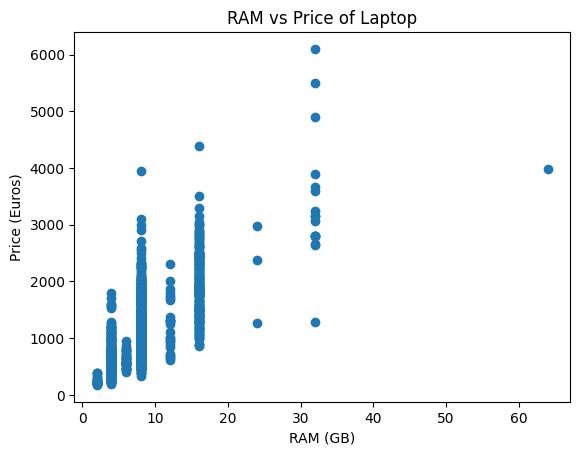

In [48]:
import matplotlib. pyplot as plt


ram = df['Ram']
price = df['Price_euros']

plt.scatter(ram, price)

plt.xlabel('RAM (GB)')
plt.ylabel('Price (Euros)')
plt.title('RAM vs Price of Laptop')

plt.show()

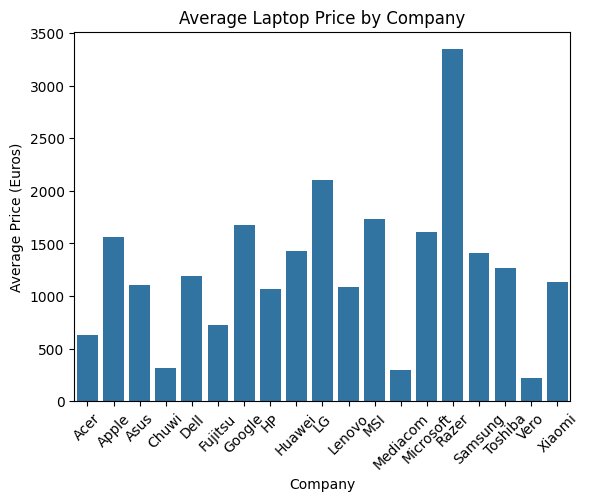

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns


avg_price_by_company = df.groupby('Company')['Price_euros'].mean()


sns.barplot(x=avg_price_by_company.index, y=avg_price_by_company.values )


plt.xlabel('Company')
plt.ylabel('Average Price (Euros)')
plt.title('Average Laptop Price by Company')


plt.xticks(rotation=45)


plt.show()

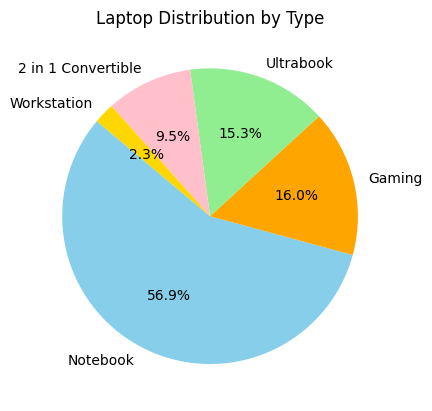

In [50]:
import matplotlib.pyplot as plt



type_counts = df['TypeName'].value_counts()

plt.pie(counts, labels=laptop_types, autopct="%1.1f%%", startangle=140, colors=['skyblue', 'orange', 'lightgreen', 'pink', 'gold'])


plt.title("Laptop Distribution by Type")

plt.show()

In [53]:
from sklearn.preprocessing import LabelEncoder

In [51]:
df_encoded = df.copy()
le = LabelEncoder()
categorical_features = ['Ram','Weight']

for col in categorical_features:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,3,128GB SSD,Intel Iris Plus Graphics 640,macOS,37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,3,128GB Flash Storage,Intel HD Graphics 6000,macOS,34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,3,256GB SSD,Intel HD Graphics 620,No OS,72,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,5,512GB SSD,AMD Radeon Pro 455,macOS,69,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,3,256GB SSD,Intel Iris Plus Graphics 650,macOS,37,1803.60


In [ ]:
 # features selections
features_to_keep = ['Company', 'TypeName', 'Ram', 'Weight', 'Price_euros']
df_selected = df[features_to_keep]

df_encoded = pd.get_dummies(df_selected, drop_first=True)

Iteration 0, w: 24.12, b: 2.25, MSE: 1750911.11
Iteration 100, w: 123.41, b: 24.36, MSE: 234610.76
Iteration 200, w: 122.31, b: 37.00, MSE: 232999.99
Iteration 300, w: 121.26, b: 48.98, MSE: 231552.32
Iteration 400, w: 120.26, b: 60.34, MSE: 230251.22
Iteration 500, w: 119.32, b: 71.11, MSE: 229081.86
Iteration 600, w: 118.43, b: 81.31, MSE: 228030.89
Iteration 700, w: 117.58, b: 90.99, MSE: 227086.33
Iteration 800, w: 116.78, b: 100.16, MSE: 226237.41
Iteration 900, w: 116.02, b: 108.86, MSE: 225474.44

Final Model: y = 115.31 * x + 117.03
Predicted Price for 16GB RAM: 1961.92 Euros


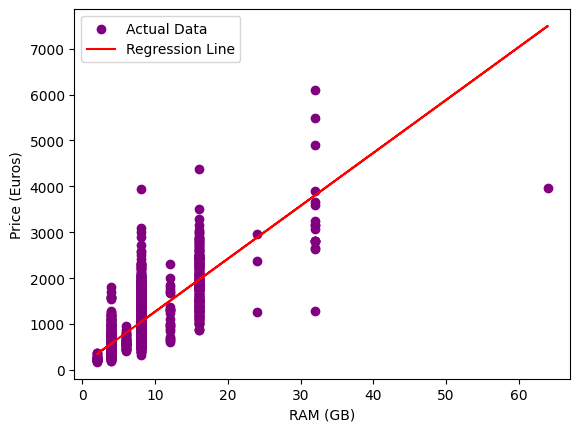

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# 1. تجهيز البيانات (الرام والسعر)
# هنستخدم البيانات اللي نظفناها قبل كدا
X = df['Ram'].values
y = df['Price_euros'].values

# 2. Initialize parameters (نفس اللي في صورتك)
w = 0.0  # الـ Weight
b = 0.0  # الـ Bias
learning_rate = 0.001 # قللنا الـ rate شوية عشان الـ RAM أرقامها كبيرة
n_iterations = 1000
m = len(X)

# 3. Gradient Descent (نفس المعادلة الرياضية)
for i in range(n_iterations):
    y_pred = w * X + b  # معادلة الخط المستقيم
    
    # حساب المشتقات (Derivatives)
    dw = (2/m) * np.sum((y_pred - y) * X)
    db = (2/m) * np.sum(y_pred - y)
    
    # تحديث القيم
    w -= learning_rate * dw
    b -= learning_rate * db
    
    # طباعة الـ Error كل 100 خطوة
    if i % 100 == 0:
        mse = (1/m) * np.sum((y_pred - y)**2)
        print(f"Iteration {i}, w: {w:.2f}, b: {b:.2f}, MSE: {mse:.2f}")

print(f"\nFinal Model: y = {w:.2f} * x + {b:.2f}")

# 4. Predict (توقع سعر لابتوب راماته 16 جيجا)
X_new = 16
y_new = w * X_new + b
print(f"Predicted Price for 16GB RAM: {y_new:.2f} Euros")

# 5. الرسم البياني (Visualization)
plt.scatter(X, y, color='purple', label='Actual Data')
plt.plot(X, w * X + b, color='red', label='Regression Line')
plt.xlabel("RAM (GB)")
plt.ylabel("Price (Euros)")
plt.legend()
plt.show()